## 1. Install dependencies

In [1]:
!pip -q install transformers datasets accelerate matplotlib tqdm

## 2. Imports

In [2]:
import json, os, textwrap, html, base64, re
from pathlib import Path
import torch
import torch.nn as nn
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModelForCausalLM
import matplotlib.pyplot as plt
from tqdm.auto import trange

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


## 3. One GSM8K example

In [3]:
example = {
    'question': 'Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May?',
    'cot_steps': [
        'Natalia sold 48/2 = 24 clips in May.',
        'Natalia sold 48+24 = 72 clips altogether.'
    ],
    'answer': '72'
}

# eos_token is passed later after the tokenizer is loaded.
# This teaches the model where to stop, so generation does not keep repeating the final sentence.
def build_training_text(example, stage=1, k_latents=2, eos_token=''):
    removed = min(stage, len(example['cot_steps']))
    remaining = example['cot_steps'][removed:]
    prompt = f"Question: {example['question']}\nAnswer:"
    latent = ' <bot>' + (' <latent>' * k_latents) + ' <eot>' if k_latents > 0 else ''
    if remaining:
        target = ' ' + ' '.join(remaining) + f" Therefore, the answer is {example['answer']}."
    else:
        target = f" The answer is {example['answer']}."

    if eos_token:
        target += eos_token

    return prompt, prompt + latent + target

prompt_text, train_text = build_training_text(example, stage=1, k_latents=2)
print(train_text)


Question: Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May?
Answer: <bot> <latent> <latent> <eot> Natalia sold 48+24 = 72 clips altogether. Therefore, the answer is 72.


## 4. Coconut model wrapper

In [4]:
SPECIAL_TOKENS = ['<bot>', '<eot>', '<latent>']

class CoconutLM(nn.Module):
    def __init__(self, model_name='Qwen/Qwen3-0.6B'):
        super().__init__()
        self.tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        added = self.tokenizer.add_special_tokens({'additional_special_tokens': SPECIAL_TOKENS})
        dtype = torch.bfloat16 if torch.cuda.is_available() else torch.float32

        self.model = AutoModelForCausalLM.from_pretrained(
            model_name,
            trust_remote_code=True,
            torch_dtype=dtype
        )

        if added > 0:
            self.model.resize_token_embeddings(len(self.tokenizer))

        self.bot_id = self.tokenizer.convert_tokens_to_ids('<bot>')
        self.eot_id = self.tokenizer.convert_tokens_to_ids('<eot>')
        self.latent_id = self.tokenizer.convert_tokens_to_ids('<latent>')

    @property
    def dev(self):
        return next(self.parameters()).device

    def tokenize(self, text):
        return self.tokenizer(text, return_tensors='pt', add_special_tokens=False)

    def make_latent_inputs_embeds(self, input_ids):
        assert input_ids.shape[0] == 1
        embed = self.model.get_input_embeddings()
        inputs_embeds = embed(input_ids).clone()
        latent_positions = (input_ids[0] == self.latent_id).nonzero(as_tuple=True)[0].tolist()

        for pos in latent_positions:
            prefix_embeds = inputs_embeds[:, :pos, :]
            attention_mask = torch.ones(prefix_embeds.shape[:2], device=prefix_embeds.device, dtype=torch.long)
            out = self.model(
                inputs_embeds=prefix_embeds,
                attention_mask=attention_mask,
                output_hidden_states=True,
                use_cache=False
            )
            prev_hidden = out.hidden_states[-1][:, -1, :]
            # No detach: gradients flow through latent thoughts.
            inputs_embeds[:, pos, :] = prev_hidden

        return inputs_embeds

    def forward(self, input_ids, labels=None):
        input_ids = input_ids.to(self.dev)
        if labels is not None:
            labels = labels.to(self.dev)

        inputs_embeds = self.make_latent_inputs_embeds(input_ids)
        attention_mask = torch.ones(input_ids.shape, device=self.dev, dtype=torch.long)

        return self.model(
            inputs_embeds=inputs_embeds,
            attention_mask=attention_mask,
            labels=labels,
            use_cache=False
        )

    @torch.no_grad()
    def generate_with_latents(self, prompt, k_latents=2, max_new_tokens=40, stop_text=None):
        self.eval()
        seed = prompt + ' <bot>' + (' <latent>' * k_latents) + ' <eot>'
        ids = self.tokenize(seed)['input_ids'].to(self.dev)

        for _ in range(max_new_tokens):
            out = self.forward(ids)
            next_id = torch.argmax(out.logits[:, -1, :], dim=-1, keepdim=True)
            ids = torch.cat([ids, next_id], dim=1)


            if self.tokenizer.eos_token_id is not None and next_id.item() == self.tokenizer.eos_token_id:
                break


            if stop_text is not None:
                decoded = self.tokenizer.decode(ids[0], skip_special_tokens=False)
                if stop_text in decoded:
                    break

        return self.tokenizer.decode(ids[0], skip_special_tokens=False)


## 5. Load Qwen3-0.6B

In [5]:
MODEL_NAME = 'Qwen/Qwen3-0.6B'
coconut = CoconutLM(MODEL_NAME).to(device)
print('Loaded on', device)
print('Special token ids:', coconut.bot_id, coconut.latent_id, coconut.eot_id)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/9.73k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/1.50G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Loaded on cuda
Special token ids: 151669 151671 151670


## 6. Loss masking

In [6]:
K_LATENTS = 2
STAGE = 1

prompt_text, train_text = build_training_text(example, stage=STAGE, k_latents=K_LATENTS, eos_token=coconut.tokenizer.eos_token)
input_ids = coconut.tokenize(train_text)['input_ids'].to(device)

labels = input_ids.clone()
labels[:] = -100

prefix_text = prompt_text + ' <bot>' + (' <latent>' * K_LATENTS) + ' <eot>'
prefix_len = coconut.tokenizer(prefix_text, return_tensors='pt', add_special_tokens=False)['input_ids'].shape[1]
labels[:, prefix_len:] = input_ids[:, prefix_len:]

print('Total tokens:', input_ids.shape[1])
print('Masked prefix tokens:', prefix_len)
print('Supervised tokens:', (labels != -100).sum().item())

Total tokens: 76
Masked prefix tokens: 50
Supervised tokens: 26


## 7. Overfit one example

In [7]:
STEPS = 200
LR = 2e-5

coconut.train()
optimizer = AdamW(coconut.parameters(), lr=LR)
losses = []

for step in trange(STEPS):
    optimizer.zero_grad(set_to_none=True)
    out = coconut(input_ids=input_ids, labels=labels)
    loss = out.loss
    loss.backward()
    torch.nn.utils.clip_grad_norm_(coconut.parameters(), 1.0)
    optimizer.step()

    losses.append(float(loss.detach().cpu()))

    if step % 10 == 0:
        print(f'step={step} loss={losses[-1]:.4f}')

print('Final loss:', losses[-1])

  0%|          | 0/200 [00:00<?, ?it/s]

step=0 loss=1.8628
step=10 loss=0.0001
step=20 loss=0.0000
step=30 loss=0.0000
step=40 loss=0.0000
step=50 loss=0.0000
step=60 loss=0.0000
step=70 loss=0.0000
step=80 loss=0.0000
step=90 loss=0.0000
step=100 loss=0.0000
step=110 loss=0.0000
step=120 loss=0.0000
step=130 loss=0.0000
step=140 loss=0.0000
step=150 loss=0.0000
step=160 loss=0.0000
step=170 loss=0.0000
step=180 loss=0.0000
step=190 loss=0.0000
Final loss: 5.208463335293345e-06


## 8. Loss curve

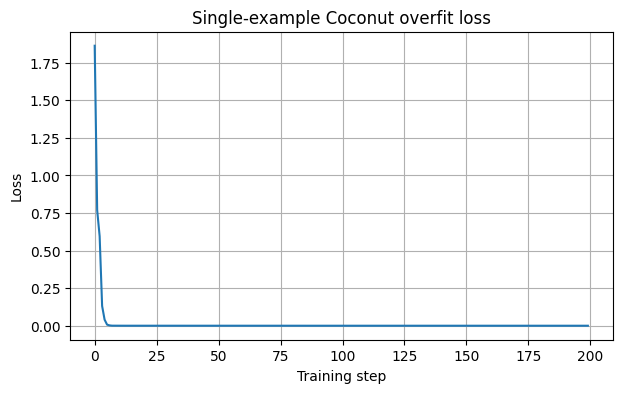

In [8]:
Path('outputs').mkdir(exist_ok=True)
plt.figure(figsize=(7,4))
plt.plot(losses)
plt.xlabel('Training step')
plt.ylabel('Loss')
plt.title('Single-example Coconut overfit loss')
plt.grid(True)
plt.savefig('outputs/loss_curve.png', dpi=160, bbox_inches='tight')
plt.show()

## 9. Generate answer without repetition

The model is trained with an EOS token and generation also stops as soon as the final answer appears once.


In [12]:
gen_prompt = f"Question: {example['question']}\nAnswer:"
stop_text = f"answer is {example['answer']}."

generated_full = coconut.generate_with_latents(
    gen_prompt,
    k_latents=K_LATENTS,
    max_new_tokens=40,
    stop_text=stop_text
)

# For a cleaner report output, keep the full text and also extract only the answer part.
generated_answer = generated_full.split('<eot>', 1)[-1].strip()
if coconut.tokenizer.eos_token:
    generated_answer = generated_answer.replace(coconut.tokenizer.eos_token, '').strip()

print('Generated text:')
print(generated_full)


results = {
    'model_name': MODEL_NAME,
    'k_latents': K_LATENTS,
    'stage': STAGE,
    'steps': STEPS,
    'final_loss': losses[-1],
    'training_text': train_text,
    'ground_truth_answer': example['answer'],
    'generated_full': generated_full,
    'generated_answer': generated_answer,
    'losses': losses,
}
Path('outputs/overfit_results.json').write_text(json.dumps(results, indent=2), encoding='utf-8');


Generated text:
Question: Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May?
Answer: <bot> <latent> <latent> <eot> Natalia sold 48+24 = 72 clips altogether. Therefore, the answer is 72.


## 10. Save checkpoint

In [13]:
save_dir = Path('outputs/overfit_model')
save_dir.mkdir(parents=True, exist_ok=True)
coconut.model.save_pretrained(save_dir)
coconut.tokenizer.save_pretrained(save_dir)
print('Saved to', save_dir)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to outputs/overfit_model


In [14]:
from google.colab import files

files.download("outputs/overfit_results.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>